**IMPORTING REQUIREMENTS**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**LOADING DATA**

In [ ]:
train = pd.read_csv("train-test.csv")
validation = pd.read_csv("validation.csv")
template = pd.read_csv("validation-predictions-template.csv")
december = pd.read_csv("december-chart-inputs.csv")

print("Train/Test:", train.shape)
print("Validation:", validation.shape)
print("Template:", template.shape)
print("December:", december.shape)

Train/Test: (48000, 14)
Validation: (12000, 13)
Template: (12000, 2)
December: (31, 7)


In [ ]:
train = pd.read_csv("train-test.csv")
validation = pd.read_csv("validation.csv")
template = pd.read_csv("validation-predictions-template.csv")
december = pd.read_csv("december-chart-inputs.csv")

print("Train/Test:", train.shape)
print("Validation:", validation.shape)
print("Template:", template.shape)
print("December:", december.shape)

Train/Test: (48000, 14)
Validation: (12000, 13)
Template: (12000, 2)
December: (31, 7)


**EXPLANATORY DATA ANALYSIS**

In [ ]:
print("Train/Test columns:")
print(train.columns.tolist())
print("\nValidation columns:")
print(validation.columns.tolist())

print("\nTemplate columns:")
print(template.columns.tolist())
print("\nDecember columns:")
print(december.columns.tolist())

Train/Test columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Validation columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

Template columns:
['load_id', 'predicted_rate']

December columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [ ]:
print("TRAIN/TEST")
train.head()

TRAIN/TEST


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [ ]:
train.describe(include="all")

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
count,48000,48000,48000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000,47700.000000,48000,47626.000000,48000.000000,48000.000000
unique,48000,64,64,NaN,NaN,NaN,NaN,NaN,3,NaN,304,NaN,NaN,NaN
top,TR-047984,Oklahoma City,Lexington,NaN,NaN,NaN,NaN,NaN,Dry Van,NaN,2025-06-17,NaN,NaN,NaN
freq,1,1242,1197,NaN,NaN,NaN,NaN,NaN,27202,NaN,198,NaN,NaN,NaN
mean,NaN,NaN,NaN,35.647545,-90.928964,35.641175,-90.857310,1135.856654,NaN,31028.844004,NaN,1.083387,2.062468,2373.980682
std,NaN,NaN,NaN,4.315285,13.482431,4.317199,13.476589,728.564416,NaN,9391.440620,NaN,0.168091,0.291391,1486.493245
min,NaN,NaN,NaN,28.357650,-121.698490,28.357650,-121.698490,70.000000,NaN,-47500.000000,NaN,0.676390,0.692280,57.220000
25%,NaN,NaN,NaN,31.986910,-98.400590,31.986910,-98.400590,550.400000,NaN,25800.000000,NaN,0.949670,1.891030,1251.555000
50%,NaN,NaN,NaN,35.294790,-88.089150,35.294790,-87.528710,953.300000,NaN,31436.500000,NaN,1.055800,2.055750,2030.760000
75%,NaN,NaN,NaN,39.411040,-83.285060,39.411040,-83.285060,1645.525000,NaN,37018.000000,NaN,1.219590,2.221685,3330.750000


In [ ]:
print("\nVALIDATION")
validation.head()


VALIDATION


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


In [ ]:
validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  object 
 1   pickup        12000 non-null  object 
 2   delivery      12000 non-null  object 
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  object 
 9   weight        11835 non-null  float64
 10  date          12000 non-null  object 
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1.2+ MB


In [ ]:
validation.describe(include="all")

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
count,12000,12000,12000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000,11835.000000,12000,11751.000000,12000.000000
unique,12000,72,72,NaN,NaN,NaN,NaN,NaN,3,NaN,61,NaN,NaN
top,TE-011984,Lexington,Bakersfield,NaN,NaN,NaN,NaN,NaN,Dry Van,NaN,2025-12-19,NaN,NaN
freq,1,301,299,NaN,NaN,NaN,NaN,NaN,6780,NaN,227,NaN,NaN
mean,NaN,NaN,NaN,35.574216,-90.724880,35.609538,-90.913530,1141.773100,NaN,30506.636248,NaN,0.926913,2.051334
std,NaN,NaN,NaN,4.366999,13.411638,4.351844,13.624744,732.333797,NaN,10572.590450,NaN,0.074109,0.219804
min,NaN,NaN,NaN,25.500000,-121.698490,25.500000,-121.698490,70.000000,NaN,-47500.000000,NaN,0.723610,1.234760
25%,NaN,NaN,NaN,31.986910,-97.226810,32.009290,-98.400590,556.100000,NaN,25493.000000,NaN,0.863880,1.903467
50%,NaN,NaN,NaN,35.294790,-87.528710,35.294790,-87.528710,953.600000,NaN,31193.000000,NaN,0.922900,2.051230
75%,NaN,NaN,NaN,39.411040,-82.783790,39.411040,-82.783790,1670.500000,NaN,36843.500000,NaN,0.992355,2.200030


In [ ]:
train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])

**OUTLIER HANDLING**

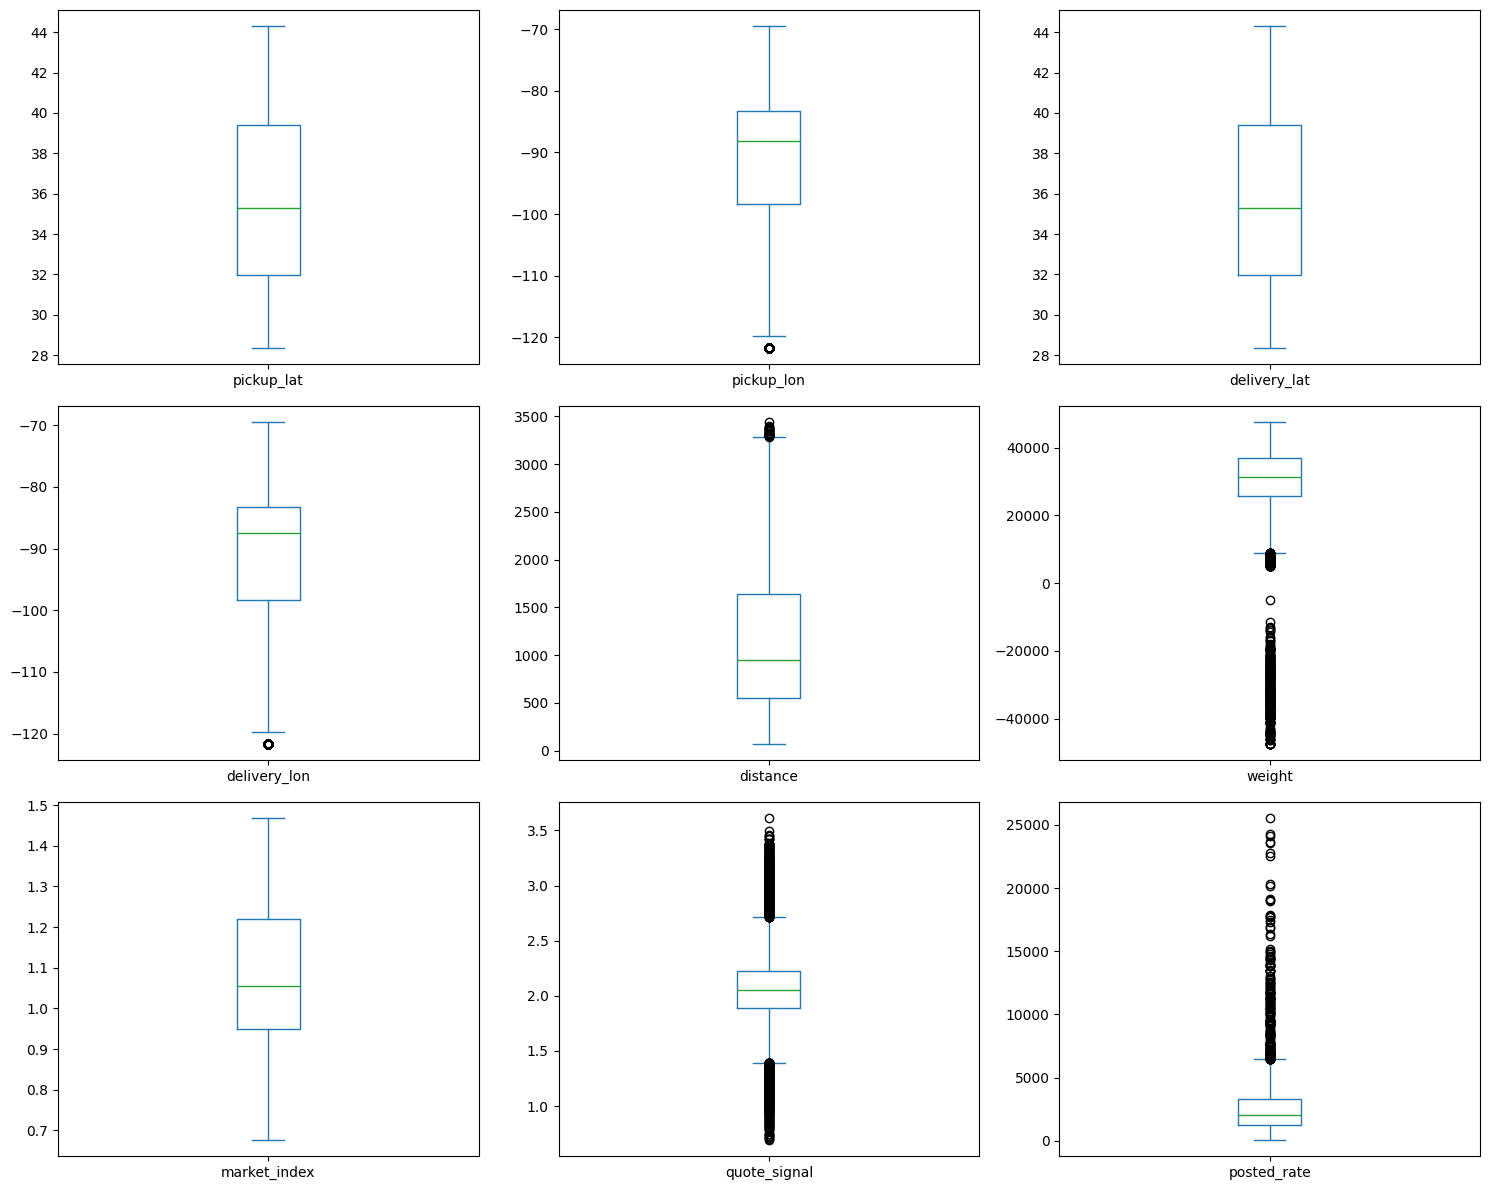

In [ ]:
train.plot.box(
    subplots=True,
    layout=(3, 3),
    figsize=(15, 12)
)

plt.tight_layout()

In [ ]:
numeric_cols = train.select_dtypes(include="number").columns
for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    below = (train[col] < lower).sum()
    above = (train[col] > upper).sum()
    print(f"{col}: below = {below}, above = {above}")

pickup_lat: below = 0, above = 0
pickup_lon: below = 453, above = 0
delivery_lat: below = 0, above = 0
delivery_lon: below = 467, above = 0
distance: below = 0, above = 32
weight: below = 424, above = 0
market_index: below = 0, above = 0
quote_signal: below = 841, above = 1115
posted_rate: below = 0, above = 260


In [ ]:
train[train["weight"] < 0][
    ["weight", "distance", "equipment", "pickup", "delivery", "posted_rate"]
].describe(include="all")

,weight,distance,equipment,pickup,delivery,posted_rate
count,292.000000,292.000000,292,292,292,292.000000
unique,NaN,NaN,3,64,62,NaN
top,NaN,NaN,Dry Van,Cincinnati,Baton Rouge,NaN
freq,NaN,NaN,155,11,10,NaN
mean,-31724.195205,1120.920205,NaN,NaN,NaN,2389.786233
std,8262.536326,733.132047,NaN,NaN,NaN,1641.761285
min,-47500.000000,75.100000,NaN,NaN,NaN,247.370000
25%,-37284.250000,531.975000,NaN,NaN,NaN,1257.410000
50%,-31821.500000,930.450000,NaN,NaN,NaN,1994.960000
75%,-25928.500000,1537.125000,NaN,NaN,NaN,3185.257500


In [ ]:
train[train["weight"] < 0][
    ["load_id", "weight", "distance", "equipment", "pickup", "delivery", "posted_rate"]
].head(20)

,load_id,weight,distance,equipment,pickup,delivery,posted_rate
68,TR-000069,-36559.0,1334.2,Reefer,Amarillo,Dayton,2831.27
204,TR-000205,-26670.0,496.2,Dry Van,Fresno,Tucson,1046.92
206,TR-000207,-20003.0,411.3,Reefer,Columbia,Raleigh,959.15
225,TR-000226,-23981.0,1317.4,Reefer,Greensboro,Lubbock,2836.00
376,TR-000377,-41397.0,1331.1,Dry Van,Madison,Providence,2522.54
446,TR-000447,-37215.0,2438.3,Reefer,Albuquerque,Albany,4841.57
495,TR-000496,-31214.0,715.9,Dry Van,Montgomery,Dayton,1473.78
641,TR-000642,-41023.0,582.4,Dry Van,Tulsa,Indianapolis,1264.33
806,TR-000807,-28320.0,676.1,Dry Van,Cincinnati,Buffalo,1307.76
1093,TR-001094,-25153.0,1058.5,Dry Van,Cincinnati,Albany,1907.83


In [ ]:
train[train["weight"] < 0]["weight"].abs().describe()

,weight
count,292.000000
mean,31724.195205
std,8262.536326
min,5000.000000
25%,25928.500000
50%,31821.500000
75%,37284.250000
max,47500.000000


In [ ]:
validation[validation["weight"] < 0][
    ["load_id", "weight", "distance", "equipment",
     "pickup", "delivery"]
].head(20)

,load_id,weight,distance,equipment,pickup,delivery
183,TE-000184,-36522.0,278.7,Dry Van,New York,Boston
205,TE-000206,-25784.0,487.4,Dry Van,Columbia,Indianapolis
357,TE-000358,-32517.0,2869.8,Flatbed,Los Angeles,New York
361,TE-000362,-32011.0,844.8,Flatbed,Oklahoma City,Atlanta
408,TE-000409,-35044.0,446.3,Dry Van,Little Rock,Cincinnati
414,TE-000415,-27284.0,990.2,Reefer,San Antonio,Indianapolis
498,TE-000499,-19374.0,1020.0,Dry Van,Hartford,Milwaukee
553,TE-000554,-41185.0,164.1,Flatbed,Cincinnati,Chattanooga
560,TE-000561,-19389.0,70.0,Dry Van,Chattanooga,Nashville
577,TE-000578,-16326.0,1178.9,Dry Van,Birmingham,Providence


In [ ]:
print("Negative weights in validation:",
      (validation["weight"] < 0).sum())

print("Total validation rows:",
      len(validation))

Negative weights in validation: 145
Total validation rows: 12000


In [ ]:
validation[validation["weight"] < 0]["weight"].describe()

,weight
count,145.000000
mean,-31681.820690
std,8094.232211
min,-47500.000000
25%,-37679.000000
50%,-32517.000000
75%,-26289.000000
max,-8229.000000


In [ ]:
train.groupby(train["weight"] < 0)["posted_rate"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
weight,,,,,
False,47708,2373.883943,2031.16,57.22,25533.00
True,292,2389.786233,1994.96,247.37,14561.21


In [ ]:
train.groupby(train["weight"] < 0)[
    ["weight", "distance", "posted_rate"]
].mean()

,weight,distance,posted_rate
weight,,,
False,31415.358674,1135.948074,2373.883943
True,-31724.195205,1120.920205,2389.786233


In [ ]:
pd.crosstab(
    train["equipment"],
    train["weight"] < 0,
    normalize="index"
) * 100

weight,False,True
equipment,,
Dry Van,99.430189,0.569811
Flatbed,99.200274,0.799726
Reefer,99.443753,0.556247


In [ ]:
train["weight_abs"] = train["weight"].abs()

train.groupby(train["weight"] < 0)["weight_abs"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
weight,,,,,
False,47408,31415.358674,31493.5,5000.0,47500.0
True,292,31724.195205,31821.5,5000.0,47500.0


In [ ]:
train["weight"] = train["weight"].abs()
validation["weight"] = validation["weight"].abs()

In [ ]:
print("Train negative weights:", (train["weight"] < 0).sum())
print("Validation negative weights:", (validation["weight"] < 0).sum())

print("\nTrain weight range:")
print(train["weight"].min(), train["weight"].max())

print("\nValidation weight range:")
print(validation["weight"].min(), validation["weight"].max())

Train negative weights: 0
Validation negative weights: 0

Train weight range:
5000.0 47500.0

Validation weight range:
5000.0 47500.0


In [ ]:
train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31417.249245,7996.515399,5000.00000,25922.00000,31496.00000,37063.250000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


In [ ]:
Q1 = train["posted_rate"].quantile(0.25)
Q3 = train["posted_rate"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("Number of lower outliers:",
      (train["posted_rate"] < lower_bound).sum())

print("Number of upper outliers:",
      (train["posted_rate"] > upper_bound).sum())

Q1: 1251.5549999999998
Q3: 3330.75
IQR: 2079.195
Lower bound: -1867.2375000000006
Upper bound: 6449.5425000000005
Number of lower outliers: 0
Number of upper outliers: 260


MISSING VALUE HANDLING

In [ ]:
print("=== TRAIN/TEST ===")
print("Duplicate rows:", train.duplicated().sum())
print("\nMissing values:")
print(train.isna().sum())

print("\n=== VALIDATION ===")
print("Duplicate rows:", validation.duplicated().sum())
print("\nMissing values:")
print(validation.isna().sum())

=== TRAIN/TEST ===
Duplicate rows: 0

Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
weight_abs      300
dtype: int64

=== VALIDATION ===
Duplicate rows: 0

Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64


In [ ]:
print("Missing weight:")
train[train["weight"].isna()].head()

Missing weight:


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,weight_abs
323,TR-000324,Richmond,San Francisco,38.09122,-76.78906,35.19670,-121.69849,2848.8,Reefer,NaN,2025-01-03,0.91370,1.92679,5430.07,NaN
648,TR-000649,Tulsa,Mobile,33.45894,-94.78556,31.80442,-88.25195,467.0,Reefer,NaN,2025-01-05,0.77536,2.48162,1178.03,NaN
694,TR-000695,Los Angeles,Fresno,28.56624,-116.70249,33.07921,-119.79528,432.6,Reefer,NaN,2025-01-05,0.84069,2.37036,1022.13,NaN
732,TR-000733,El Paso,Hartford,33.31075,-110.31230,39.55328,-72.18051,2497.6,Reefer,NaN,2025-01-05,0.79026,2.01004,4991.60,NaN
911,TR-000912,Washington,Kansas City,38.87577,-77.05086,39.41104,-91.12450,887.8,Dry Van,NaN,2025-01-06,0.81120,1.85853,1643.25,NaN


In [ ]:
print("\nMissing market_index:")
train[train["market_index"].isna()].head()


Missing market_index:


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,weight_abs
116,TR-000117,Memphis,Fort Wayne,35.56802,-89.52871,41.31561,-85.36206,533.8,Reefer,30570.0,2025-01-01,NaN,2.37177,1271.10,30570.0
226,TR-000227,Tampa,Hartford,28.35765,-86.94782,39.55328,-72.18051,1342.7,Reefer,26397.0,2025-01-02,NaN,2.01837,2743.13,26397.0
311,TR-000312,Los Angeles,New York,28.56624,-116.70249,40.00674,-73.79840,2935.7,Flatbed,32807.0,2025-01-02,NaN,1.91236,5568.57,32807.0
511,TR-000512,Grand Rapids,Amarillo,43.43800,-86.29173,33.17137,-104.36789,1420.7,Reefer,19360.0,2025-01-04,NaN,1.94596,2786.63,19360.0
531,TR-000532,Richmond,San Antonio,38.09122,-76.78906,29.50969,-98.40059,1624.7,Reefer,39452.0,2025-01-04,NaN,2.04970,3295.80,39452.0


In [ ]:
print(pd.crosstab(train["weight"].isna(), train["market_index"].isna()))

market_index  False  True 
weight                    
False         47327    373
True            299      1


In [ ]:
print("Train/Test missing percentage:")
print((train.isna().sum() / len(train) * 100).round(2))

print("\nValidation missing percentage:")
print((validation.isna().sum() / len(validation) * 100).round(2))

Train/Test missing percentage:
load_id         0.00
pickup          0.00
delivery        0.00
pickup_lat      0.00
pickup_lon      0.00
delivery_lat    0.00
delivery_lon    0.00
distance        0.00
equipment       0.00
weight          0.62
date            0.00
market_index    0.78
quote_signal    0.00
posted_rate     0.00
weight_abs      0.62
dtype: float64

Validation missing percentage:
load_id         0.00
pickup          0.00
delivery        0.00
pickup_lat      0.00
pickup_lon      0.00
delivery_lat    0.00
delivery_lon    0.00
distance        0.00
equipment       0.00
weight          1.38
date            0.00
market_index    2.08
quote_signal    0.00
dtype: float64


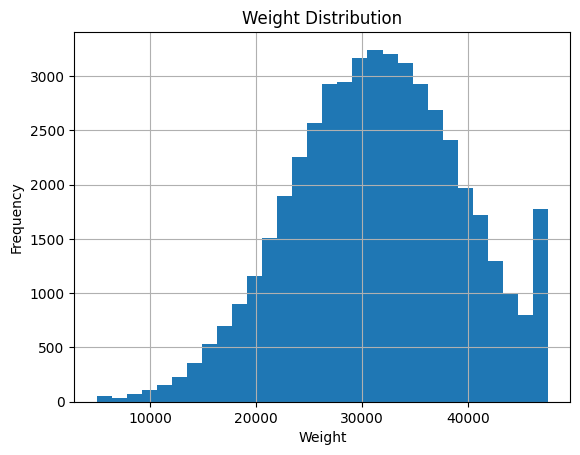

In [ ]:
train["weight"].hist(bins=30)
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Weight Distribution")
plt.show()

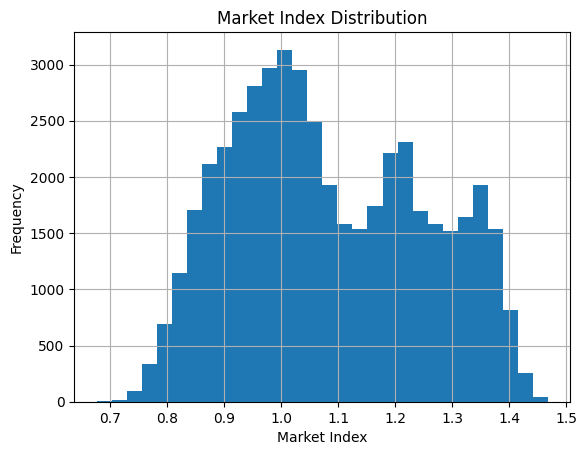

In [ ]:
train["market_index"].hist(bins=30)
plt.xlabel("Market Index")
plt.ylabel("Frequency")
plt.title("Market Index Distribution")
plt.show()

In [ ]:
print("Weight median:", train["weight"].median())
print("Market index median:", train["market_index"].median())

Weight median: 31496.0
Market index median: 1.0558


In [ ]:
weight_median = train["weight"].median()
market_median = train["market_index"].median()

train["weight"] = train["weight"].fillna(weight_median)
train["market_index"] = train["market_index"].fillna(market_median)

validation["weight"] = validation["weight"].fillna(weight_median)
validation["market_index"] = validation["market_index"].fillna(market_median)

In [ ]:
print("Train date type:", train["date"].dtype)
print("Validation date type:", validation["date"].dtype)

print("\nTrain date range:")
print(train["date"].min(), "to", train["date"].max())

print("\nValidation date range:")
print(validation["date"].min(), "to", validation["date"].max())

Train date type: datetime64[ns]
Validation date type: datetime64[ns]

Train date range:
2025-01-01 00:00:00 to 2025-10-31 00:00:00

Validation date range:
2025-11-01 00:00:00 to 2025-12-31 00:00:00


In [ ]:
print("Train unique dates:", train["date"].nunique())
print("Validation unique dates:", validation["date"].nunique())

Train unique dates: 304
Validation unique dates: 61


In [ ]:
print(train["date"].head(10))

0   2025-01-01
1   2025-01-01
2   2025-01-01
3   2025-01-01
4   2025-01-01
5   2025-01-01
6   2025-01-01
7   2025-01-01
8   2025-01-01
9   2025-01-01
Name: date, dtype: datetime64[ns]


**FEATURE ENGINEERING**

In [ ]:
for df in [train, validation]:
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

In [ ]:
print(train[[
    "date",
    "month",
    "day",
    "day_of_week",
    "week_of_year"
]].head(10))

        date  month  day  day_of_week  week_of_year
0 2025-01-01      1    1            2             1
1 2025-01-01      1    1            2             1
2 2025-01-01      1    1            2             1
3 2025-01-01      1    1            2             1
4 2025-01-01      1    1            2             1
5 2025-01-01      1    1            2             1
6 2025-01-01      1    1            2             1
7 2025-01-01      1    1            2             1
8 2025-01-01      1    1            2             1
9 2025-01-01      1    1            2             1


In [ ]:
train["distance_log"] = np.log1p(train["distance"])
validation["distance_log"] = np.log1p(validation["distance"])

In [ ]:
train["weight_distance_ratio"] = train["weight"] / train["distance"]
validation["weight_distance_ratio"] = validation["weight"] / validation["distance"]

In [ ]:
print(train[[
    "distance",
    "distance_log",
    "weight",
    "weight_distance_ratio"
]].describe().T)

                         count          mean          std          min  \
distance               48000.0   1135.856654   728.564416    70.000000   
distance_log           48000.0      6.799190     0.739436     4.262680   
weight                 48000.0  31417.741438  7971.489014  5000.000000   
weight_distance_ratio  48000.0     47.744949    51.173649     2.051871   

                               25%           50%           75%           max  
distance                 550.40000    953.300000   1645.525000   3439.800000  
distance_log               6.31246      6.860978      7.406422      8.143459  
weight                 25961.00000  31496.000000  37018.000000  47500.000000  
weight_distance_ratio     18.69038     32.140968     56.339969    678.571429  


In [ ]:
train.nlargest(10, "weight_distance_ratio")[
    [
        "load_id",
        "pickup",
        "delivery",
        "distance",
        "weight",
        "weight_distance_ratio",
        "equipment",
        "posted_rate"
    ]
]

,load_id,pickup,delivery,distance,weight,weight_distance_ratio,equipment,posted_rate
9348,TR-009349,Shreveport,New Orleans,70.0,47500.0,678.571429,Flatbed,232.33
24219,TR-024220,Cincinnati,Louisville,70.0,46866.0,669.514286,Flatbed,233.81
40321,TR-040322,Nashville,Chattanooga,71.3,46022.0,645.469846,Reefer,247.85
46283,TR-046284,Hartford,Philadelphia,74.8,47500.0,635.026738,Flatbed,236.51
5091,TR-005092,New Orleans,Shreveport,70.0,44407.0,634.385714,Dry Van,210.14
25525,TR-025526,Hartford,Philadelphia,70.0,43660.0,623.714286,Reefer,579.90
6182,TR-006183,Philadelphia,Hartford,70.0,42969.0,613.842857,Flatbed,208.43
45779,TR-045780,Louisville,Cincinnati,70.0,42558.0,607.971429,Dry Van,210.54
11311,TR-011312,Lubbock,Austin,70.0,42249.0,603.557143,Flatbed,240.46
20894,TR-020895,Hartford,Philadelphia,73.0,43835.0,600.479452,Dry Van,214.33


In [ ]:
same_lat = train["pickup_lat"] == train["delivery_lat"]
same_lon = train["pickup_lon"] == train["delivery_lon"]

print("Same latitude:", same_lat.sum())
print("Same longitude:", same_lon.sum())
print("Same coordinates:", (same_lat & same_lon).sum())

Same latitude: 0
Same longitude: 10
Same coordinates: 0


In [ ]:
for df in [train, validation]:
    df["lat_diff"] = df["delivery_lat"] - df["pickup_lat"]
    df["lon_diff"] = df["delivery_lon"] - df["pickup_lon"]

In [ ]:
print(train[[
    "pickup_lat",
    "delivery_lat",
    "lat_diff",
    "pickup_lon",
    "delivery_lon",
    "lon_diff"
]].head(10))

   pickup_lat  delivery_lat  lat_diff  pickup_lon  delivery_lon  lon_diff
0    38.09122      38.16908   0.07786   -76.78906     -72.74564   4.04342
1    38.09122      39.22317   1.13195   -76.78906     -72.96710   3.82196
2    39.22317      44.30296   5.07979   -72.96710     -87.52871 -14.56161
3    39.55328      34.84933  -4.70395   -72.18051     -86.28940 -14.10889
4    31.83025      35.29479   3.46454   -94.38343     -88.08915   6.29428
5    28.75668      28.61374  -0.14294  -115.87725     -95.89569  19.98156
6    33.07921      29.50969  -3.56952  -119.79528     -98.40059  21.39469
7    35.19670      39.41104   4.21434  -121.69849     -91.12450  30.57399
8    33.28832      31.37602  -1.91230  -116.67935     -86.10743  30.57192
9    35.39918      28.75668  -6.64250  -109.59792    -115.87725  -6.27933


In [ ]:
print(train[["lat_diff", "lon_diff"]].describe())

           lat_diff      lon_diff
count  48000.000000  48000.000000
mean      -0.006370      0.071654
std        6.129317     19.179127
min      -15.945310    -52.198490
25%       -4.347990    -12.031660
50%       -0.025420      0.162800
75%        4.416470     12.289240
max       15.945310     52.198490


**DISTANCE FEATURE CHECK**

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 3958.8
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [ ]:
for df in [train, validation]:
    df["geo_distance"] = haversine_distance(
        df["pickup_lat"],
        df["pickup_lon"],
        df["delivery_lat"],
        df["delivery_lon"]
    )

In [ ]:
train[["distance", "geo_distance"]].describe()

,distance,geo_distance
count,48000.000000,48000.000000
mean,1135.856654,966.154360
std,728.564416,630.650711
min,70.000000,7.265240
25%,550.400000,456.537929
50%,953.300000,806.935637
75%,1645.525000,1410.670791
max,3439.800000,2873.652583


In [ ]:
print(
    train[["distance", "geo_distance"]]
    .corr()
)

              distance  geo_distance
distance      1.000000      0.999535
geo_distance  0.999535      1.000000


In [ ]:
train.drop(columns=["geo_distance"], inplace=True)
validation.drop(columns=["geo_distance"], inplace=True)

**CATEGORICAL VALUES HANDLING**

In [ ]:
categorical_cols = ["pickup", "delivery", "equipment"]

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", train[col].nunique())


pickup
Unique values: 64

delivery
Unique values: 64

equipment
Unique values: 3


In [ ]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(train[col].value_counts().head(20))


=== pickup ===
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Cincinnati       1080
Shreveport       1062
Kansas City      1053
Columbia         1049
Atlanta          1029
San Antonio       972
Philadelphia      946
Los Angeles       945
Milwaukee         944
Tucson            944
Name: count, dtype: int64

=== delivery ===
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Cincinnati       1084
Columbia         1071
Nashville        1064
Tucson            997
Shreveport        983
Kansas City       980
San Antonio       965
Philadelphia      959
Los Angeles       955
Syracuse          926
Name: count, dtype: int64

=== equipment ===

In [ ]:
for col in ["pickup", "delivery", "equipment"]:
    train_categories = set(train[col].dropna().unique())
    validation_categories = set(validation[col].dropna().unique())

    print(f"\n{col}")
    print("Train categories:", len(train_categories))
    print("Validation categories:", len(validation_categories))
    print("Categories only in validation:",
          validation_categories - train_categories)
    print("Categories only in train:",
          train_categories - validation_categories)


pickup
Train categories: 64
Validation categories: 72
Categories only in validation: {'Norfolk', 'Chicago', 'Charlotte', 'Laredo', 'Knoxville', 'Jackson', 'Allentown', 'San Diego'}
Categories only in train: set()

delivery
Train categories: 64
Validation categories: 72
Categories only in validation: {'Norfolk', 'Charlotte', 'Chicago', 'Laredo', 'Knoxville', 'Jackson', 'Allentown', 'San Diego'}
Categories only in train: set()

equipment
Train categories: 3
Validation categories: 3
Categories only in validation: set()
Categories only in train: set()


In [ ]:
numeric_features = train.select_dtypes(include="number").columns

corr = train[numeric_features].corr()["posted_rate"].sort_values(
    ascending=False
)

print(corr)

posted_rate              1.000000
distance                 0.908519
distance_log             0.853788
weight_abs               0.041343
weight                   0.041229
market_index             0.034022
week_of_year             0.024562
month                    0.023804
day                      0.010305
lat_diff                -0.000801
lon_diff                -0.001347
day_of_week             -0.003383
quote_signal            -0.039858
pickup_lat              -0.090873
delivery_lat            -0.091970
pickup_lon              -0.255058
delivery_lon            -0.257086
weight_distance_ratio   -0.569401
Name: posted_rate, dtype: float64


In [ ]:
train.drop(columns=["weight_abs"], inplace=True, errors="ignore")
validation.drop(columns=["weight_abs"], inplace=True, errors="ignore")

MODEL PREPARATION

In [ ]:
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
numeric_features = [
    "pickup_lat","pickup_lon",
    "delivery_lat","delivery_lon",
    "distance","distance_log",
    "weight","weight_distance_ratio",
    "market_index","quote_signal",
    "month","day_of_week",
    "week_of_year"]
categorical_features = ["equipment"]

X = train[numeric_features + categorical_features]
y = train["posted_rate"]

In [ ]:
X_en = pd.get_dummies(X, drop_first=False)
y_en = train["posted_rate"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_en,y_en,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(38400, 16)
(9600, 16)
(38400,)
(9600,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38400 entries, 596 to 15795
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pickup_lat             38400 non-null  float64
 1   pickup_lon             38400 non-null  float64
 2   delivery_lat           38400 non-null  float64
 3   delivery_lon           38400 non-null  float64
 4   distance               38400 non-null  float64
 5   distance_log           38400 non-null  float64
 6   weight                 38400 non-null  float64
 7   weight_distance_ratio  38400 non-null  float64
 8   market_index           38400 non-null  float64
 9   quote_signal           38400 non-null  float64
 10  month                  38400 non-null  int32  
 11  day_of_week            38400 non-null  int32  
 12  week_of_year           38400 non-null  int64  
 13  equipment_Dry Van      38400 non-null  bool   
 14  equipment_Flatbed      38400 non-null  bool   
 15  equip

In [ ]:
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_train)
y_pred_1_test = model_1.predict(X_test)

In [ ]:
print("Training:")
print("MAE :", mean_absolute_error(y_train, y_pred_1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_1)))
print("R²  :", r2_score(y_train, y_pred_1))

print("\nTesting:")
print("MAE :", mean_absolute_error(y_test, y_pred_1_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_1_test)))
print("R²  :", r2_score(y_test, y_pred_1_test))

Training:
MAE : 137.4620482458696
RMSE: 612.5067536826746
R²  : 0.8315642057816232

Testing:
MAE : 131.19463316829507
RMSE: 533.8503677639088
R²  : 0.8667390924191797


In [ ]:
model_2 = DecisionTreeRegressor(random_state=42)
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_train)
y_pred_2_test = model_2.predict(X_test)

In [ ]:
print("Training:")
print("MAE :", mean_absolute_error(y_train, y_pred_2))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_2)))
print("R²  :", r2_score(y_train, y_pred_2))

print("\nTesting:")
print("MAE :", mean_absolute_error(y_test, y_pred_2_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_2_test)))
print("R²  :", r2_score(y_test, y_pred_2_test))

Training:
MAE : 0.0
RMSE: 0.0
R²  : 1.0

Testing:
MAE : 172.37278958333334
RMSE: 886.0375666344397
R²  : 0.6329138951607167


**HYPER PARAMETER TUNING**

In [ ]:
param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=model_2,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_mean_absolute_error')

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)
model_2_tuned = grid_search.best_estimator_

y_pred_2_tuned = model_2_tuned.predict(X_train)
y_pred_2_tuned_test = model_2_tuned.predict(X_test)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best CV MAE:
157.41557188004282


In [ ]:
print("Training:")
print("MAE :", mean_absolute_error(y_train, y_pred_2_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_2_tuned)))
print("R²  :", r2_score(y_train, y_pred_2_tuned))

print("\nTesting:")
print("MAE :", mean_absolute_error(y_test, y_pred_2_tuned_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_2_tuned_test)))
print("R²  :", r2_score(y_test, y_pred_2_tuned_test))

Training:
MAE : 123.35043863465803
RMSE: 557.1716968842229
R²  : 0.8606231261026764

Testing:
MAE : 151.9860997307239
RMSE: 579.7620666022889
R²  : 0.8428323111126916


In [ ]:
model_3 = RandomForestRegressor(n_estimators=200,
    random_state=42,n_jobs=-1)

model_3.fit(X_train, y_train)

y_pred_3 = model_3.predict(X_train)
y_pred_3_test = model_3.predict(X_test)

In [ ]:
print("Training:")
print("MAE :", mean_absolute_error(y_train, y_pred_3))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_3)))
print("R²  :", r2_score(y_train, y_pred_3))

print("\nTesting:")
print("MAE :", mean_absolute_error(y_test, y_pred_3_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_3_test)))
print("R²  :", r2_score(y_test, y_pred_3_test))

Training:
MAE : 49.9448348919271
RMSE: 234.59976256154482
R²  : 0.9752902835544196

Testing:
MAE : 127.79176155729161
RMSE: 563.6486028229606
R²  : 0.8514473019886539


In [ ]:
model_4 = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

model_4.fit(X_train, y_train)

y_pred_4 = model_4.predict(X_train)
y_pred_4_test = model_4.predict(X_test)

In [ ]:
print("Training:")
print("MAE :", mean_absolute_error(y_train, y_pred_4))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_4)))
print("R²  :", r2_score(y_train, y_pred_4))

print("\nTesting:")
print("MAE :", mean_absolute_error(y_test, y_pred_4_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_4_test)))
print("R²  :", r2_score(y_test, y_pred_4_test))

Training:
MAE : 118.82095201578865
RMSE: 559.6400258769711
R²  : 0.8593854824079857

Testing:
MAE : 120.73361404416461
RMSE: 535.691221312238
R²  : 0.8658184720280889


In [ ]:
param_dist_hgb = {
    "max_iter": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 30],
    "l2_regularization": [0, 0.1, 1]
}

random_search_hgb = RandomizedSearchCV(
    estimator=model_4,
    param_distributions=param_dist_hgb,
    n_iter=8,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)
random_search_hgb.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=HistGradientBoostingRegressor(max_iter=200,
                                                           random_state=42),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'l2_regularization': [0, 0.1, 1],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_iter': [100, 200, 300],
                                        'max_leaf_nodes': [15, 31, 63],
                                        'min_samples_leaf': [10, 20, 30]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [ ]:
print("Best Parameters:")
print(random_search_hgb.best_params_)

print("\nBest CV MAE:")
print(-random_search_hgb.best_score_)

model_4_tuned = random_search_hgb.best_estimator_
y_pred_4_tuned = model_4_tuned.predict(X_train)
y_pred_4_tuned_test = model_4_tuned.predict(X_test)

Best Parameters:
{'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 200, 'learning_rate': 0.03, 'l2_regularization': 1}

Best CV MAE:
125.7974557000897


In [ ]:
print("Training:")
print("MAE :", mean_absolute_error(y_train, y_pred_4_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_4_tuned)))
print("R²  :", r2_score(y_train, y_pred_4_tuned))

print("\nTesting:")
print("MAE :", mean_absolute_error(y_test, y_pred_4_tuned_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_4_tuned_test)))
print("R²  :", r2_score(y_test, y_pred_4_tuned_test))

Training:
MAE : 119.13688414849965
RMSE: 565.8015733240301
R²  : 0.8562721507620501

Testing:
MAE : 119.53889053133516
RMSE: 533.4435406871752
R²  : 0.8669421211758368


**BEST HYPERPARAMETERS**

In [ ]:
print("Best Parameters:")
print(random_search_hgb.best_params_)

print("\nBest CV MAE:")
print(-random_search_hgb.best_score_)

Best Parameters:
{'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 200, 'learning_rate': 0.03, 'l2_regularization': 1}

Best CV MAE:
125.7974557000897


**FINAL MODEL**

In [ ]:
final_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.03,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1,
    random_state=42
)

final_model.fit(X_en, Y_en)

HistGradientBoostingRegressor(l2_regularization=1, learning_rate=0.03,
                              max_iter=200, random_state=42)

**VALIDATION DATA EXPLORING**

In [ ]:
validation_en = pd.get_dummies(
    validation[[
            "pickup_lat","pickup_lon",
            "delivery_lat","delivery_lon",
            "distance","distance_log",
            "weight","weight_distance_ratio",
            "market_index","quote_signal",
            "month","day_of_week",
            "week_of_year","equipment"]],
    columns=["equipment"],dtype=int)

In [ ]:
validation_en = validation_en.reindex(
    columns=X_en.columns,
    fill_value=0
)

In [ ]:
print(validation_en.shape)
print(validation_en.columns.tolist())
print(validation_en.isna().sum().sum())

(12000, 16)
['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'distance_log', 'weight', 'weight_distance_ratio', 'market_index', 'quote_signal', 'month', 'day_of_week', 'week_of_year', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer']
0


In [ ]:
validation_predictions = final_model.predict(validation_en)

print("Number of predictions:", len(validation_predictions))
print("First 10 predictions:")
print(validation_predictions[:10])

Number of predictions: 12000
First 10 predictions:
[ 873.52424115 5097.55780264 5767.28890035 4152.70364736 1833.91054108
 4438.13001431 5354.63212684 2864.37333069 1115.85285814 1205.56683085]


In [ ]:
print("Minimum prediction:", validation_predictions.min())
print("Maximum prediction:", validation_predictions.max())
print("Mean prediction:", validation_predictions.mean())

Minimum prediction: 325.9821088169827
Maximum prediction: 7845.346682807119
Mean prediction: 2407.686657185126


**CREATING PREDICTION FILE**

In [ ]:
template = pd.read_csv("validation-predictions-template.csv")

template["predicted_rate"] = validation_predictions

print(template.head(10))
print(template.shape)
print(template.isna().sum())

     load_id  predicted_rate
0  TE-000001      873.524241
1  TE-000002     5097.557803
2  TE-000003     5767.288900
3  TE-000004     4152.703647
4  TE-000005     1833.910541
5  TE-000006     4438.130014
6  TE-000007     5354.632127
7  TE-000008     2864.373331
8  TE-000009     1115.852858
9  TE-000010     1205.566831
(12000, 2)
load_id           0
predicted_rate    0
dtype: int64


In [ ]:
template.to_csv("validation_predictions.csv",index=False)

print("validation_predictions.csv created successfully")

validation_predictions.csv created successfully


**DECEMBER CHART DATA PREPARATION**

In [ ]:
december = pd.read_csv(r"december-chart-inputs.csv")

print(december.shape)
print(december.info())

(31, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pickup          31 non-null     object 
 1   delivery        31 non-null     object 
 2   distance        31 non-null     int64  
 3   equipment       31 non-null     object 
 4   weight          31 non-null     int64  
 5   date            31 non-null     object 
 6   predicted_rate  0 non-null      float64
dtypes: float64(1), int64(2), object(4)
memory usage: 1.8+ KB
None


In [ ]:
print(december.columns.tolist())
print(december.head())

['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
      pickup    delivery  distance equipment  weight        date  \
0  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   

   predicted_rate  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  


In [ ]:
print(
    train.groupby("pickup")[["pickup_lat", "pickup_lon"]]
    .nunique()
    .max()
)

print(
    train.groupby("delivery")[["delivery_lat", "delivery_lon"]]
    .nunique()
    .max()
)

pickup_lat    1
pickup_lon    1
dtype: int64
delivery_lat    1
delivery_lon    1
dtype: int64


In [ ]:
features_city = [
    "pickup",
    "delivery",
    "equipment",
    "distance",
    "distance_log",
    "weight",
    "weight_distance_ratio",
    "month",
    "day_of_week",
    "week_of_year"
]

X_city = train[features_city].copy()
y_city = train["posted_rate"].copy()

X_city = pd.get_dummies(
    X_city,
    columns=["pickup", "delivery", "equipment"],
    dtype=int
)

print("X_city shape:", X_city.shape)
print("\nFeatures:")
print(X_city.columns.tolist())

X_city shape: (48000, 138)

Features:
['distance', 'distance_log', 'weight', 'weight_distance_ratio', 'month', 'day_of_week', 'week_of_year', 'pickup_Albany', 'pickup_Albuquerque', 'pickup_Amarillo', 'pickup_Atlanta', 'pickup_Austin', 'pickup_Bakersfield', 'pickup_Baltimore', 'pickup_Baton Rouge', 'pickup_Birmingham', 'pickup_Boston', 'pickup_Buffalo', 'pickup_Charleston', 'pickup_Chattanooga', 'pickup_Cincinnati', 'pickup_Columbia', 'pickup_Corpus Christi', 'pickup_Dallas', 'pickup_Dayton', 'pickup_Detroit', 'pickup_El Paso', 'pickup_Fort Wayne', 'pickup_Fresno', 'pickup_Grand Rapids', 'pickup_Green Bay', 'pickup_Greensboro', 'pickup_Harrisburg', 'pickup_Hartford', 'pickup_Houston', 'pickup_Indianapolis', 'pickup_Jacksonville', 'pickup_Kansas City', 'pickup_Las Vegas', 'pickup_Lexington', 'pickup_Little Rock', 'pickup_Los Angeles', 'pickup_Louisville', 'pickup_Lubbock', 'pickup_Madison', 'pickup_Memphis', 'pickup_Milwaukee', 'pickup_Mobile', 'pickup_Montgomery', 'pickup_Nashville', 'p

In [ ]:
X_train_city, X_test_city, y_train_city, y_test_city = train_test_split(
    X_city,
    y_city,
    test_size=0.2,
    random_state=42
)

print("X_train_city:", X_train_city.shape)
print("X_test_city :", X_test_city.shape)
print("y_train_city:", y_train_city.shape)
print("y_test_city :", y_test_city.shape)

X_train_city: (38400, 138)
X_test_city : (9600, 138)
y_train_city: (38400,)
y_test_city : (9600,)


**MODEL CREATION**

In [ ]:
city_rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

city_rf.fit(X_train_city, y_train_city)

y_train_pred_city_rf = city_rf.predict(X_train_city)
y_test_pred_city_rf = city_rf.predict(X_test_city)

print("Training Results")
print("MAE :", mean_absolute_error(y_train_city, y_train_pred_city_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_train_city, y_train_pred_city_rf)))
print("R²  :", r2_score(y_train_city, y_train_pred_city_rf))

print("\nTesting Results")
print("MAE :", mean_absolute_error(y_test_city, y_test_pred_city_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_city, y_test_pred_city_rf)))
print("R²  :", r2_score(y_test_city, y_test_pred_city_rf))

Training Results
MAE : 59.16996647916666
RMSE: 246.34026916838522
R²  : 0.972755211018902

Testing Results
MAE : 147.933179375
RMSE: 577.7047028189029
R²  : 0.8439457933570251


In [ ]:
city_hgb = HistGradientBoostingRegressor(
    max_iter=200,learning_rate=0.03,
    max_leaf_nodes=31,min_samples_leaf=20,
    l2_regularization=1,random_state=42)

city_hgb.fit(X_train_city, y_train_city)

y_train_pred_city = city_hgb.predict(X_train_city)
y_test_pred_city = city_hgb.predict(X_test_city)

In [ ]:
print("Training Results")
print("MAE :", mean_absolute_error(y_train_city, y_train_pred_city))
print("RMSE:", np.sqrt(mean_squared_error(y_train_city, y_train_pred_city)))
print("R²  :", r2_score(y_train_city, y_train_pred_city))

print("\nTesting Results")
print("MAE :", mean_absolute_error(y_test_city, y_test_pred_city))
print("RMSE:", np.sqrt(mean_squared_error(y_test_city, y_test_pred_city)))
print("R²  :", r2_score(y_test_city, y_test_pred_city))

Training Results
MAE : 125.42499064728472
RMSE: 572.5959675745625
R²  : 0.852799530317444

Testing Results
MAE : 124.35485550955504
RMSE: 534.3043750160168
R²  : 0.866512335453159


**MODEL PREDICTION**

In [ ]:
december["date"] = pd.to_datetime(december["date"])
december["month"] = december["date"].dt.month
december["day_of_week"] = december["date"].dt.dayofweek
december["week_of_year"] = december["date"].dt.isocalendar().week.astype(int)

december["distance_log"] = np.log1p(december["distance"])
december["weight_distance_ratio"] = december["weight"] / december["distance"]

december_en = pd.get_dummies(
    december[["pickup","delivery","equipment","distance","distance_log",
            "weight","weight_distance_ratio","month","day_of_week",
            "week_of_year"]],
    columns=["pickup", "delivery", "equipment"],dtype=int)

december_en = december_en.reindex(
    columns=X_city.columns,
    fill_value=0
)

december["predicted_rate"] = city_hgb.predict(december_en)
print(december[["pickup", "delivery", "date", "predicted_rate"]])

       pickup    delivery       date  predicted_rate
0   Lexington  Fort Wayne 2025-12-01      901.840396
1   Lexington  Fort Wayne 2025-12-02      901.840396
2   Lexington  Fort Wayne 2025-12-03      901.840396
3   Lexington  Fort Wayne 2025-12-04      901.840396
4   Lexington  Fort Wayne 2025-12-05      901.840396
5   Lexington  Fort Wayne 2025-12-06      901.840396
6   Lexington  Fort Wayne 2025-12-07      901.840396
7   Lexington  Fort Wayne 2025-12-08      901.840396
8   Lexington  Fort Wayne 2025-12-09      901.840396
9   Lexington  Fort Wayne 2025-12-10      901.840396
10  Lexington  Fort Wayne 2025-12-11      901.840396
11  Lexington  Fort Wayne 2025-12-12      901.840396
12  Lexington  Fort Wayne 2025-12-13      901.840396
13  Lexington  Fort Wayne 2025-12-14      901.840396
14  Lexington  Fort Wayne 2025-12-15      901.840396
15  Lexington  Fort Wayne 2025-12-16      901.840396
16  Lexington  Fort Wayne 2025-12-17      901.840396
17  Lexington  Fort Wayne 2025-12-18      901.

In [ ]:
december_output = december[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "predicted_rate"
    ]
].copy()

december_output.to_csv(
    "december_chart_inputs.csv",
    index=False
)

print("Columns:")
print(december_output.columns.tolist())

print("\nShape:", december_output.shape)

print("\nMissing predicted_rate:",
      december_output["predicted_rate"].isna().sum())

print("\nFirst 5 rows:")
print(december_output.head())

Columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

Shape: (31, 7)

Missing predicted_rate: 0

First 5 rows:
      pickup    delivery  distance equipment  weight       date  \
0  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-05   

   predicted_rate  
0      901.840396  
1      901.840396  
2      901.840396  
3      901.840396  
4      901.840396  
